# Notebook 4 — Correlation vs. causation

Notebook 3 controlled for one confounder (`territory_score`) and got two different outcomes: `crm_usage`'s correlation collapsed to zero (it was a confound), while `calls_made`'s stayed strong and significant — controlling for territory didn't touch it, because territory was never its actual problem.

That leaves an open question this notebook answers: **if controlling for a confounder doesn't explain a correlation away, does that mean it's causal?** Not necessarily — there are several distinct reasons a correlation can survive, and confounding is only one of them.

- **Part A** names these reasons explicitly, each with a diagram, plus a checklist for what it actually takes to call something causal.
- **Part B** applies this back to `calls_made` and closes out what this dataset alone can and can't tell us.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style="white")

ACCENT = "#2a78d6"      # solid = a real causal link
NEGATIVE = "#e34948"    # dashed = an observed correlation, not itself a causal claim
NEUTRAL = "#9a9990"     # ~zero / no relationship
BOX_COLOR = "#52514e"   # neutral ink for boxes/text — color carries meaning only on the arrows

DATA_DIR = Path("../data")
rng = np.random.default_rng(21)  # local RNG for this notebook's toy examples only


def draw_node(ax, xy, text, width=2.0, height=0.9):
    x, y = xy
    box = mpatches.FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.05,rounding_size=0.12",
        linewidth=1.5, edgecolor=BOX_COLOR, facecolor="white", zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=11, color=BOX_COLOR, zorder=3)


def draw_edge(ax, start, end, color=ACCENT, style="solid", curve=0.0, label=None, label_dy=0.35,
              arrowstyle="-|>", shrinkA=42, shrinkB=42):
    arrow = mpatches.FancyArrowPatch(
        start, end, arrowstyle=arrowstyle, mutation_scale=16,
        linewidth=2, color=color, linestyle=style,
        connectionstyle=f"arc3,rad={curve}", zorder=1,
        shrinkA=shrinkA, shrinkB=shrinkB,
    )
    ax.add_patch(arrow)
    if label:
        mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + label_dy + curve * 2
        ax.text(mx, my, label, ha="center", va="center", fontsize=9, color=color)


def new_diagram_axes(ax, title):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=11, color="#1a1a19")


def residualize(values, z):
    """Return `values` with everything a straight-line fit on z explains removed. (Same helper as notebook 3.)"""
    fit = stats.linregress(z, values)
    return values - (fit.slope * z + fit.intercept)

## Part A — Four shapes a correlation can hide

In every diagram below: a **solid blue arrow** is a real causal link (something we, as the simulation's authors, built in on purpose). A **dashed red arrow** is what a naive correlation between two variables would show — an observed association, not a causal claim. The whole point of these four diagrams is that all four produce a correlation between X and Y that can look identical on a scatter plot, for completely different underlying reasons.

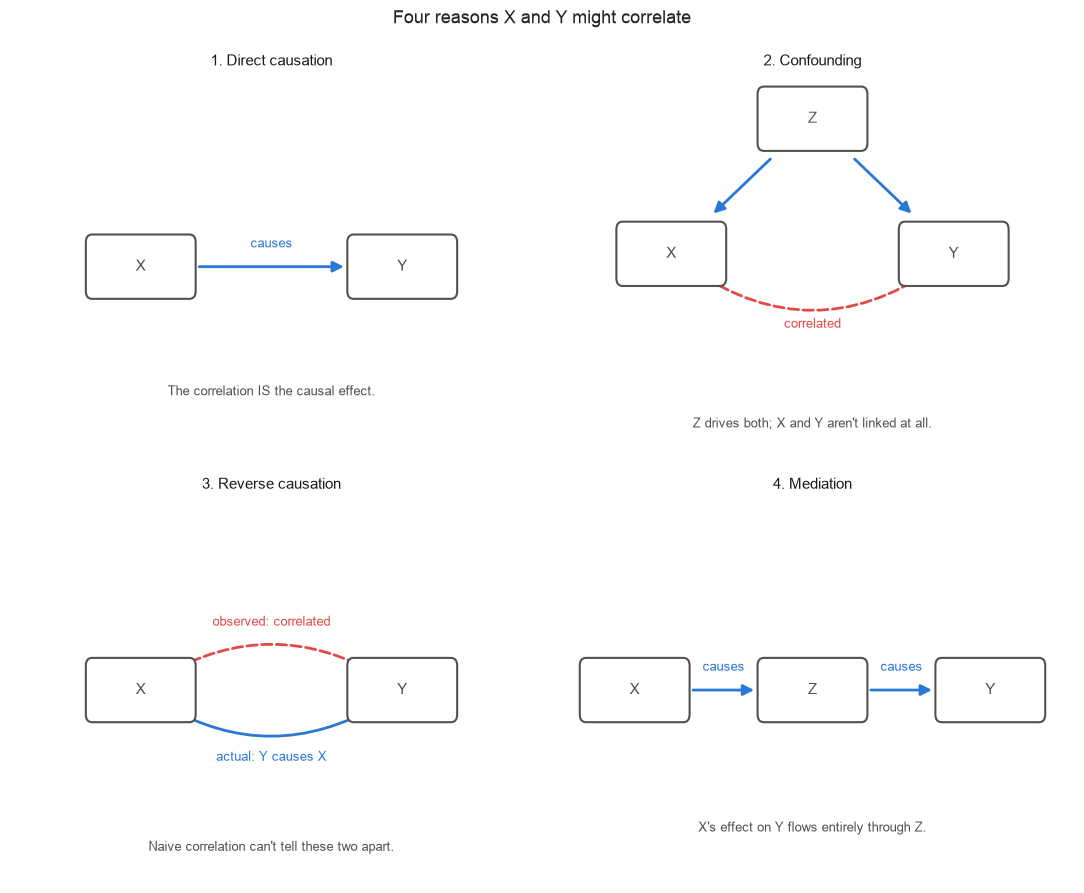

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# --- 1. Direct causation ---
ax = axes[0, 0]
new_diagram_axes(ax, "1. Direct causation")
draw_node(ax, (2.5, 3), "X")
draw_node(ax, (7.5, 3), "Y")
draw_edge(ax, (2.5, 3), (7.5, 3), color=ACCENT, label="causes")
ax.text(5, 1.0, "The correlation IS the causal effect.", ha="center", fontsize=9, color="#52514e")

# --- 2. Confounding ---
ax = axes[0, 1]
new_diagram_axes(ax, "2. Confounding")
draw_node(ax, (5, 5.3), "Z")
draw_node(ax, (2.3, 3.2), "X")
draw_node(ax, (7.7, 3.2), "Y")
draw_edge(ax, (5, 5.3), (2.3, 3.2), color=ACCENT)
draw_edge(ax, (5, 5.3), (7.7, 3.2), color=ACCENT)
draw_edge(ax, (2.3, 3.2), (7.7, 3.2), color=NEGATIVE, style="dashed", arrowstyle="-", curve=0.4, shrinkA=20, shrinkB=20)
ax.text(5, 2.05, "correlated", ha="center", fontsize=9, color=NEGATIVE)
ax.text(5, 0.5, "Z drives both; X and Y aren't linked at all.", ha="center", fontsize=9, color="#52514e")

# --- 3. Reverse causation ---
ax = axes[1, 0]
new_diagram_axes(ax, "3. Reverse causation")
draw_node(ax, (2.5, 3), "X")
draw_node(ax, (7.5, 3), "Y")
draw_edge(ax, (2.5, 3), (7.5, 3), color=NEGATIVE, style="dashed", arrowstyle="-", curve=-0.35, shrinkA=20, shrinkB=20)
draw_edge(ax, (7.5, 3), (2.5, 3), color=ACCENT, curve=-0.35, shrinkA=20, shrinkB=20)
ax.text(5, 4.0, "observed: correlated", ha="center", fontsize=9, color=NEGATIVE)
ax.text(5, 1.9, "actual: Y causes X", ha="center", fontsize=9, color=ACCENT)
ax.text(5, 0.5, "Naive correlation can't tell these two apart.", ha="center", fontsize=9, color="#52514e")

# --- 4. Mediation ---
ax = axes[1, 1]
new_diagram_axes(ax, "4. Mediation")
draw_node(ax, (1.6, 3), "X")
draw_node(ax, (5, 3), "Z")
draw_node(ax, (8.4, 3), "Y")
draw_edge(ax, (1.6, 3), (5, 3), color=ACCENT, label="causes")
draw_edge(ax, (5, 3), (8.4, 3), color=ACCENT, label="causes")
ax.text(5, 0.8, "X's effect on Y flows entirely through Z.", ha="center", fontsize=9, color="#52514e")

fig.suptitle("Four reasons X and Y might correlate", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()

## The mediation trap

Notebook 3's whole lesson was "control for a third variable, and a spurious correlation shrinks toward zero." Mediation produces the exact same statistical symptom — a correlation that shrinks toward zero once you control for Z — for the **opposite reason**: not because the X-Y link was fake, but because Z is the real mechanism X uses to affect Y in the first place. Control for it, and you're not removing noise — you're removing the effect itself.

Toy example, nothing to do with sales: exercise → endorphins → mood. We'll build in a direct causal link from exercise to endorphins, and from endorphins to mood — but **no direct link from exercise to mood at all**. Any effect of exercise on mood has to travel through endorphins.

In [3]:
n_people = 200
exercise = np.clip(rng.normal(30, 12, n_people), 0, None)          # minutes of exercise
endorphins = 2.0 * exercise + rng.normal(0, 25, n_people)           # exercise -> endorphins (real)
mood = 0.8 * endorphins + rng.normal(0, 12, n_people)               # endorphins -> mood (real)
# note: mood's formula never references exercise directly — every effect is mediated

mediation_toy = pd.DataFrame({"exercise": exercise, "endorphins": endorphins, "mood": mood})
mediation_toy.head()

,exercise,endorphins,mood
0,34.305281,54.756798,61.568488
1,48.128128,40.240045,25.518044
2,8.564025,-0.593537,-0.682812
3,50.239362,83.329541,74.340575
4,29.432193,82.705112,69.808841


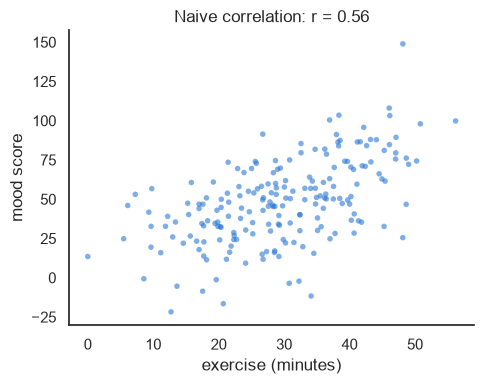

r(exercise, mood) = 0.5586  — and this one is genuinely real: exercise really does affect mood, via endorphins


In [4]:
r_naive_med = stats.pearsonr(exercise, mood).statistic

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(exercise, mood, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.set_xlabel("exercise (minutes)")
ax.set_ylabel("mood score")
ax.set_title(f"Naive correlation: r = {r_naive_med:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"r(exercise, mood) = {r_naive_med:.4f}  — and this one is genuinely real: exercise really does affect mood, via endorphins")

Following notebook 3's playbook exactly — "control for the third variable" — using the same `residualize()` function on `endorphins` instead of `territory_score`:

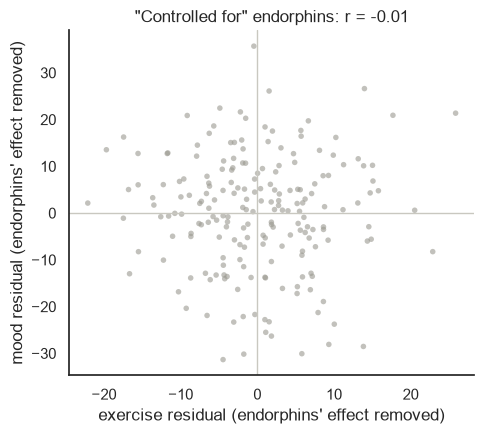

naive r(exercise, mood)                        = 0.5586
r, controlling for endorphins (the mediator)   = -0.0113  (p = 0.873)


In [5]:
resid_exercise = residualize(exercise, endorphins)
resid_mood = residualize(mood, endorphins)
r_partial_med, p_partial_med = stats.pearsonr(resid_exercise, resid_mood)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.axhline(0, color="#c9c8c0", linewidth=1)
ax.axvline(0, color="#c9c8c0", linewidth=1)
ax.scatter(resid_exercise, resid_mood, s=16, alpha=0.6, color=NEUTRAL, edgecolor="none")
ax.set_xlabel("exercise residual (endorphins' effect removed)")
ax.set_ylabel("mood residual (endorphins' effect removed)")
ax.set_title(f"\"Controlled for\" endorphins: r = {r_partial_med:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"naive r(exercise, mood)                        = {r_naive_med:.4f}")
print(f"r, controlling for endorphins (the mediator)   = {r_partial_med:.4f}  (p = {p_partial_med:.3f})")

A real, substantial effect (r ≈ 0.56) collapsed to essentially nothing (r ≈ -0.01, not significant) — from the exact same mechanical step that correctly cleared `crm_usage` in notebook 3. The arithmetic doesn't know the difference; only knowing *where Z sits* tells you which situation you're in:

| | Confounder | Mediator |
|---|---|---|
| **Where Z sits** | Before both X and Y (Z → X, Z → Y) | Between X and Y (X → Z → Y) |
| **Controlling for Z** | Removes a spurious link — correct | Removes a real effect — wrong |
| **Example here** | territory_score (notebook 3) | endorphins (this section) |

**The math is identical in both cases — regress out Z, correlate what's left. It cannot tell you which table row you're in.** Only your own understanding of the mechanism — does Z plausibly happen *before* X and Y, independently causing both? Or does Z plausibly happen *because of* X, on the way to affecting Y? — tells you whether controlling for it is the right move or a mistake. Get this wrong, and correcting a confound and erasing a real effect look statistically indistinguishable from the outside.

## Simpson's paradox: when pooling doesn't just weaken a relationship, it flips it

Confounding, so far, has meant "a correlation that looks stronger than it should." Simpson's paradox is the more dramatic version: pooled data can show a relationship pointing in the **opposite direction** from what's true in every subgroup.

Toy example, two classes: study hours vs. test score. Within each class, more hours really does mean a better score. But Class B is simply a harder class (lower scores at every hour level) — and its students happen to study more. Watch what happens when we pool both classes together and ignore which class each student is in.

In [6]:
n_students = 100
hours_a = rng.normal(2, 0.7, n_students)
score_a = 70 + 5 * hours_a + rng.normal(0, 4, n_students)   # Class A: easier, studies less

hours_b = rng.normal(6, 0.7, n_students)
score_b = 40 + 5 * hours_b + rng.normal(0, 4, n_students)   # Class B: harder, studies more

simpson = pd.DataFrame({
    "hours": np.concatenate([hours_a, hours_b]),
    "score": np.concatenate([score_a, score_b]),
    "class": ["A"] * n_students + ["B"] * n_students,
})
simpson.head()

,hours,score,class
0,1.068342,71.164842,A
1,1.519419,76.018310,A
2,0.899854,75.346095,A
3,2.227150,93.798771,A
4,3.119285,82.385188,A


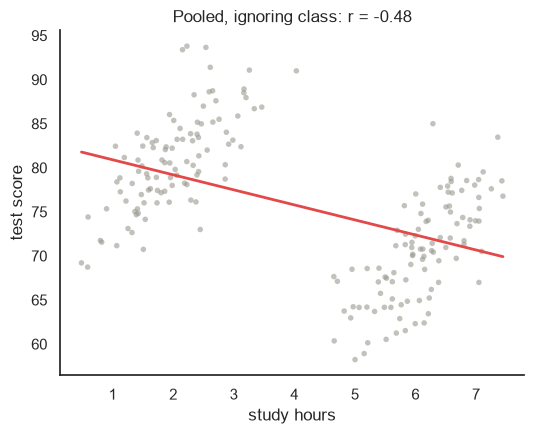

pooled r(hours, score) = -0.4824  — "studying more predicts a WORSE score"?!


In [7]:
r_pooled = stats.pearsonr(simpson["hours"], simpson["score"]).statistic
pooled_fit = stats.linregress(simpson["hours"], simpson["score"])
hours_order = np.sort(simpson["hours"].to_numpy())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(simpson["hours"], simpson["score"], s=16, alpha=0.6, color=NEUTRAL, edgecolor="none")
ax.plot(hours_order, pooled_fit.intercept + pooled_fit.slope * hours_order, color=NEGATIVE, linewidth=2)
ax.set_xlabel("study hours")
ax.set_ylabel("test score")
ax.set_title(f"Pooled, ignoring class: r = {r_pooled:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"pooled r(hours, score) = {r_pooled:.4f}  — \"studying more predicts a WORSE score\"?!")

Same data, no new points — just colored by which class each student is in:

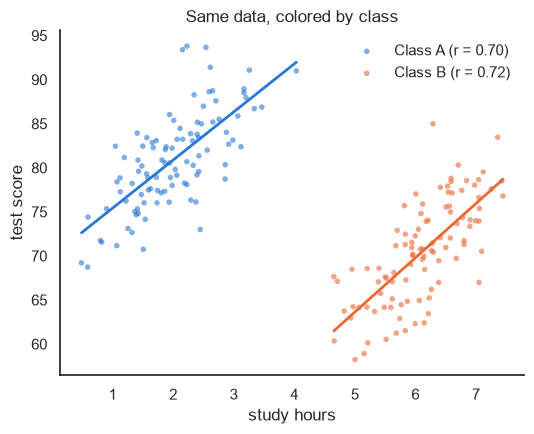

In [8]:
CLASS_COLORS = {"A": ACCENT, "B": "#eb6834"}

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color in CLASS_COLORS.items():
    subset = simpson[simpson["class"] == cls]
    r_class = stats.pearsonr(subset["hours"], subset["score"]).statistic
    fit_class = stats.linregress(subset["hours"], subset["score"])
    x_order = np.sort(subset["hours"].to_numpy())
    ax.scatter(subset["hours"], subset["score"], s=16, alpha=0.6, color=color, edgecolor="none", label=f"Class {cls} (r = {r_class:.2f})")
    ax.plot(x_order, fit_class.intercept + fit_class.slope * x_order, color=color, linewidth=2)
ax.set_xlabel("study hours")
ax.set_ylabel("test score")
ax.set_title("Same data, colored by class")
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Within each class, more hours clearly means a better score — both slopes point the same way, up. The pooled trend pointed *down* only because Class B occupies the low-score, high-hours corner of the plot and Class A occupies the high-score, low-hours corner: pooling swaps which axis dominates the picture.

This is confounding again, just with a categorical confounder (which class a student is in) instead of a continuous one, and strong enough to flip the sign rather than merely inflate it. Same fix as notebook 3: control for it. `residualize()` works the same way whether `z` is continuous (`territory_score`) or a 0/1 category indicator — regress `hours` and `score` on class, correlate what's left:

In [9]:
class_indicator = (simpson["class"] == "B").astype(float).to_numpy()  # 0 = Class A, 1 = Class B

resid_hours = residualize(simpson["hours"].to_numpy(), class_indicator)
resid_score = residualize(simpson["score"].to_numpy(), class_indicator)
r_partial_simpson = stats.pearsonr(resid_hours, resid_score).statistic

print(f"pooled r (ignoring class)      = {r_pooled:.4f}   <- backwards")
print(f"partial r (controlling for class) = {r_partial_simpson:.4f}   <- matches the within-class slopes")

pooled r (ignoring class)      = -0.4824   <- backwards
partial r (controlling for class) = 0.7080   <- matches the within-class slopes


The practical warning: **which grouping you pool over is a choice, and it's never neutral.** Whenever a dataset mixes clearly different subgroups — different classes, different territories, different time periods — check whether the pooled trend agrees with the trend inside each subgroup before trusting it. If they disagree, the subgroup-level view is the one to believe.

## A checklist for calling something causal

Four shapes, one paradox — the pattern across all of Part A is that a correlation coefficient, by itself, never says *why* X and Y move together. Before calling a relationship causal, here's what to actually check:

| Question | What it's asking | Can this dataset alone answer it? |
|---|---|---|
| **Temporal precedence** | Did X happen before Y? | No — one row per rep, no timeline. This is exactly what's missing for `calls_made`. |
| **Consistency across contexts** | Does the relationship hold up within every relevant subgroup, not just pooled? | Partially — Simpson's paradox showed this is checkable, but only for subgroups you think to check. |
| **No plausible confounding left** | Have you controlled for every real common cause, not just the convenient ones? | Partially — we controlled for `territory_score`; nothing rules out an unmeasured one. |
| **A believable mechanism, correctly placed** | Is there a plausible story for *how* X affects Y — and does a third variable sit *before* X and Y (confounder, control for it) or *between* them (mediator, don't)? | Only through reasoning about the mechanism, not from the correlation itself. |
| **Reverse causation ruled out** | Could Y plausibly be causing X instead? | Only through reasoning and domain knowledge — again, no timeline to check directly. |
| **Responds to intervention** | If you experimentally *change* X, does Y change? | No — this needs an actual experiment, not another regression on the same data. |

The first five get you to *plausibly causal* — a defensible, reasoned belief. Only the sixth gets you to *proven*, and no amount of clever analysis of this dataset can substitute for it. That's the subject of notebook 5.

## Part B — Running `calls_made` through the checklist

Back to `sales_activity_data.csv` — still no peeking at `ground_truth.json`. Notebook 2 found `calls_made` naively correlated with revenue; notebook 3 found that correlation barely moved after controlling for `territory_score`. Let's recompute both, then work through the rest of the checklist.

In [10]:
df = pd.read_csv(DATA_DIR / "sales_activity_data.csv")

r_naive_calls = stats.pearsonr(df["calls_made"], df["revenue"]).statistic
resid_calls = residualize(df["calls_made"].to_numpy(), df["territory_score"].to_numpy())
resid_revenue_calls = residualize(df["revenue"].to_numpy(), df["territory_score"].to_numpy())
r_partial_calls, p_partial_calls = stats.pearsonr(resid_calls, resid_revenue_calls)

print(f"naive r(calls_made, revenue)                     = {r_naive_calls:.4f}")
print(f"partial r(calls_made, revenue | territory_score) = {r_partial_calls:.4f}  (p = {p_partial_calls:.2e})")
print("Controlling for territory barely moved it — territory was never the issue here.")

naive r(calls_made, revenue)                     = 0.4061
partial r(calls_made, revenue | territory_score) = 0.3577  (p = 1.62e-13)
Controlling for territory barely moved it — territory was never the issue here.


### Checking consistency across contexts

Simpson's paradox showed pooled and subgroup trends can disagree. Let's rule that out here directly: split reps into three territory bands and check whether `calls_made` still correlates with revenue *within* each one, the same way we checked Class A and Class B separately.

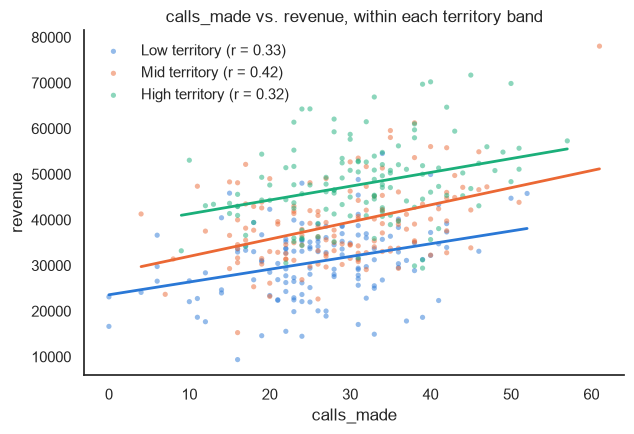

In [11]:
df["territory_band"] = pd.qcut(df["territory_score"], 3, labels=["Low", "Mid", "High"])
BAND_COLORS = {"Low": ACCENT, "Mid": "#eb6834", "High": "#1baf7a"}

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for band, color in BAND_COLORS.items():
    subset = df[df["territory_band"] == band]
    r_band = stats.pearsonr(subset["calls_made"], subset["revenue"]).statistic
    fit_band = stats.linregress(subset["calls_made"], subset["revenue"])
    x_order = np.sort(subset["calls_made"].to_numpy())
    ax.scatter(subset["calls_made"], subset["revenue"], s=14, alpha=0.5, color=color, edgecolor="none", label=f"{band} territory (r = {r_band:.2f})")
    ax.plot(x_order, fit_band.intercept + fit_band.slope * x_order, color=color, linewidth=2)
ax.set_xlabel("calls_made")
ax.set_ylabel("revenue")
ax.set_title("calls_made vs. revenue, within each territory band")
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Positive and significant in every band (r ≈ 0.33, 0.42, 0.33; all p < 0.001) — this isn't a Simpson's-paradox artifact where pooling across territories manufactured a correlation that isn't really there. Whatever's driving the `calls_made`-revenue relationship, it shows up consistently, not just when territories are lumped together.

That's two checklist items addressed with actual evidence: **no confounding left from territory** (notebook 3), and **consistent across territory contexts** (just now). Both checks came back clean. The remaining items can't be settled with this dataset — only reasoned about:

| Checklist item | Reasoning for `calls_made` |
|---|---|
| **Temporal precedence** | Unknown — no timestamps in this data. |
| **A believable mechanism, correctly placed** | Two competing stories are *equally* plausible: (a) making more calls generates more deals → more revenue, or (b) reps with fuller pipelines already have more live deals to follow up on, so they naturally make more calls — the calls are downstream of the pipeline, not the cause of it. |
| **Reverse causation ruled out** | Not ruled out — story (b) above is a completely ordinary account of how sales work, and it would produce exactly the correlation we're seeing without `calls_made` driving revenue at all. |
| **Responds to intervention** | Untested. This is the only thing that would actually distinguish (a) from (b). |

Both stories predict the *same* correlation, the *same* survival of controlling for territory, and the *same* consistency across territory bands. Nothing in this dataset can break the tie.

## Where this leaves us

Four notebooks in, here's the honest state of each activity, using only what a real analyst — without access to `ground_truth.json` — could actually establish:

- **`crm_usage`**: correlated, but the correlation was fully explained by `territory_score`. Best current read: **not causal**.
- **`training_completed`**: never correlated with anything in the first place. Best current read: **no relationship**.
- **`demos_given`, `proposals_sent`**: correlated, survive controlling for territory (and get *stronger*), consistent with a real effect. Best current read: **plausibly causal** — passed every check available, though "passed the checks we ran" is still not the same as "proven."
- **`calls_made`**: correlated, survives controlling for territory, and holds up consistently across territory bands. But an equally good non-causal story (reverse causation) explains the exact same pattern, and nothing in this dataset can rule it out. Best current read: **genuinely unresolved**.

That last one is exactly why notebook 5 exists. Passing every check available in observational data — no known confounders, consistent everywhere you look — still isn't proof, because some questions (temporal order, response to intervention) simply aren't answerable from a snapshot of who-did-what-and-sold-how-much. Notebook 5 builds the one tool that can answer them: a randomized experiment, plus what to do when running one isn't possible.